In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\yash0\Downloads\archive\train.csv", encoding='latin1')
print(df.shape)
print(df.head())

(9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID 

In [4]:
# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Shape: (9800, 18)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID        

In [5]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (9800, 18)

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

print("Date columns fixed!")
print(df[['Order Date', 'Order Month', 'Order Year']].head())

Date columns fixed!
  Order Date  Order Month  Order Year
0 2017-11-08           11        2017
1 2017-11-08           11        2017
2 2017-06-12            6        2017
3 2016-10-11           10        2016
4 2016-10-11           10        2016


In [7]:
# Category wise total sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Category wise Sales:")
print(category_sales)

Category wise Sales:
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


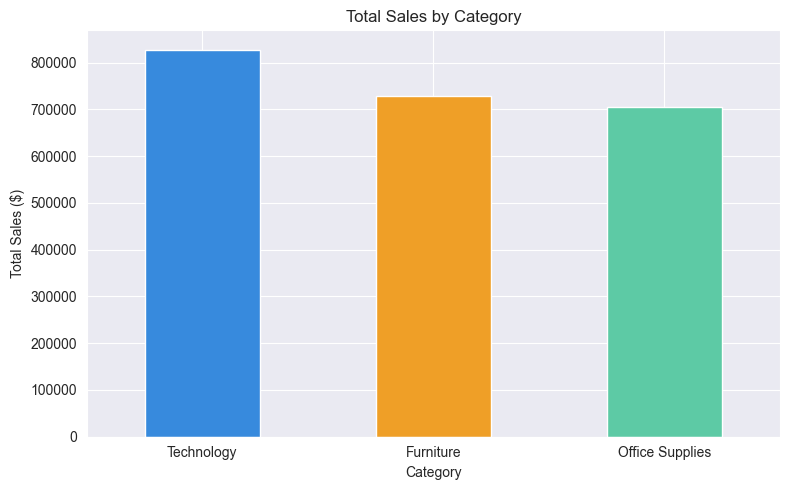

In [8]:
# Chart
plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color=['#378ADD', '#EF9F27', '#5DCAA5'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Region wise Sales:
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


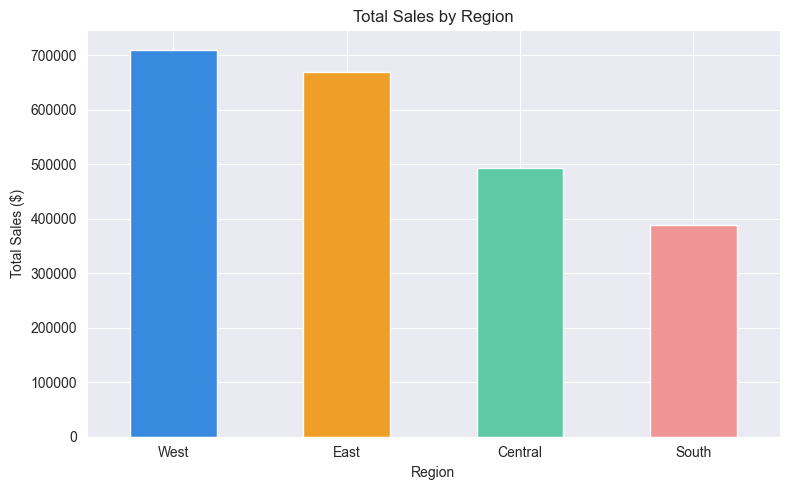

In [9]:
# Region wise sales
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("Region wise Sales:")
print(region_sales)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color=['#378ADD', '#EF9F27', '#5DCAA5', '#F09595'])
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


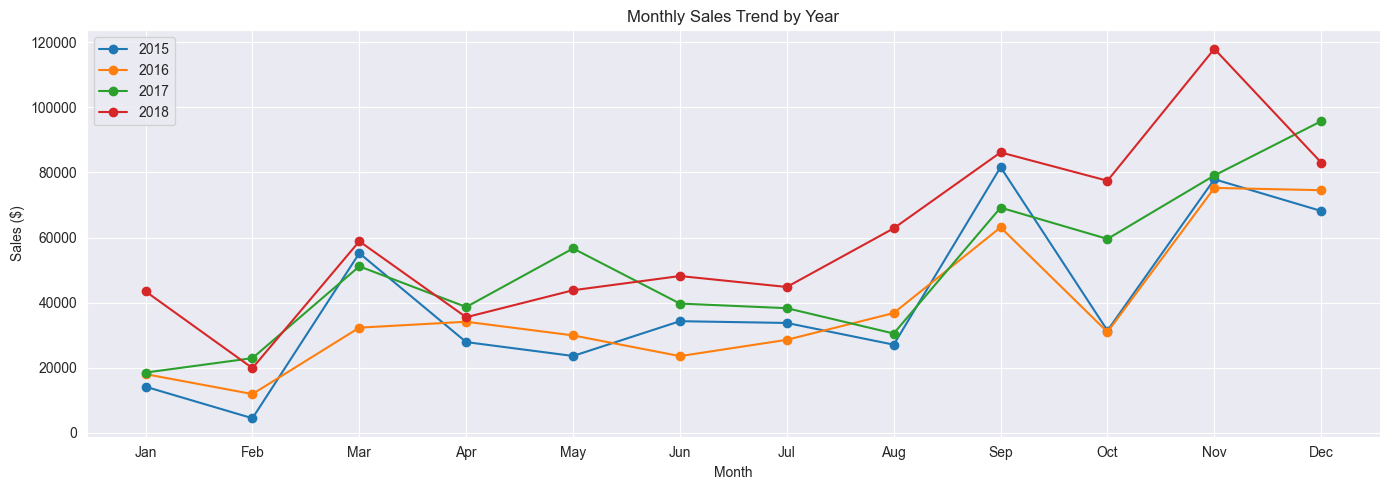

In [10]:
# Monthly sales trend
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
for year in monthly_sales['Order Year'].unique():
    data = monthly_sales[monthly_sales['Order Year'] == year]
    plt.plot(data['Order Month'], data['Sales'], marker='o', label=str(year))

plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

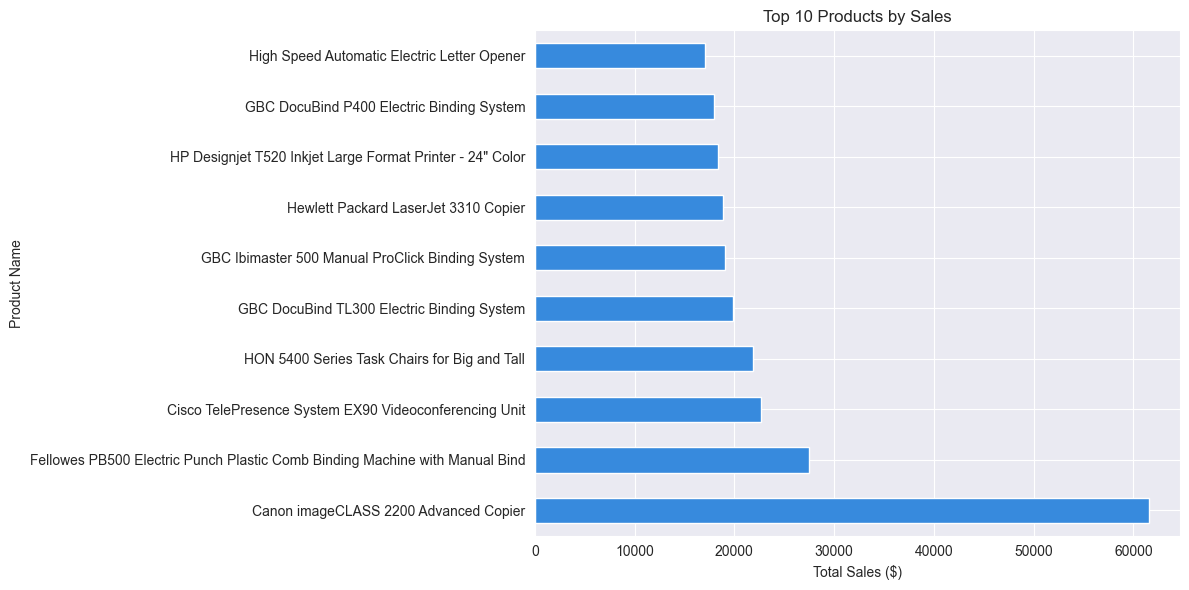

In [11]:
# Top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='barh', color='#378ADD')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


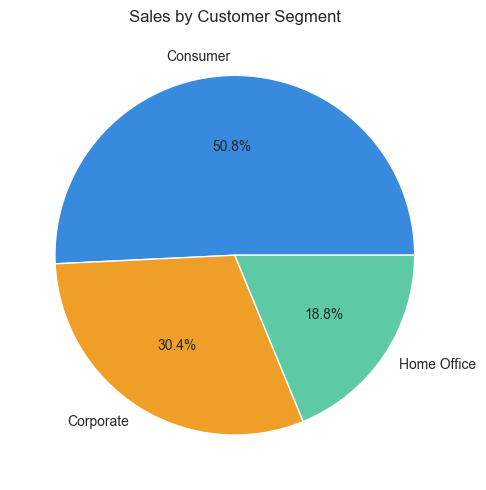

In [12]:
# Segment wise sales
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print(segment_sales)

plt.figure(figsize=(8, 5))
plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%',
        colors=['#378ADD', '#EF9F27', '#5DCAA5'])
plt.title('Sales by Customer Segment')
plt.tight_layout()
plt.show()

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


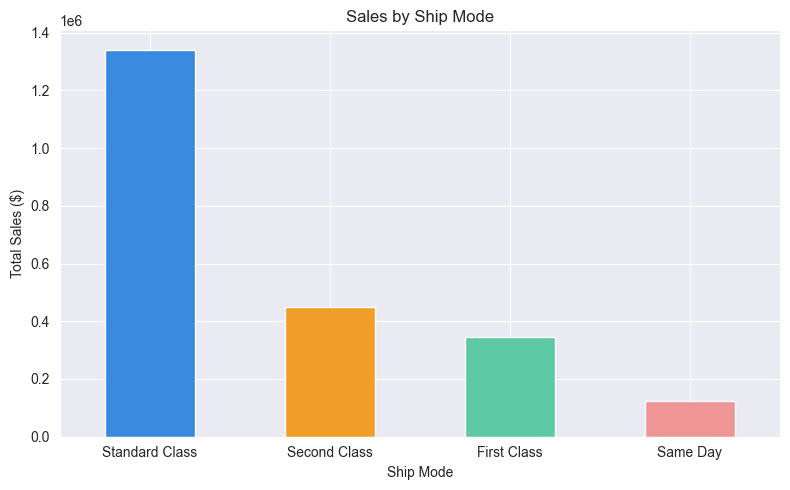

In [13]:
# Ship Mode wise sales
ship_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)
print(ship_sales)

plt.figure(figsize=(8, 5))
ship_sales.plot(kind='bar', color=['#378ADD', '#EF9F27', '#5DCAA5', '#F09595'])
plt.title('Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
df.to_csv('ecommerce_clean.csv', index=False)
print("File saved!")

File saved!


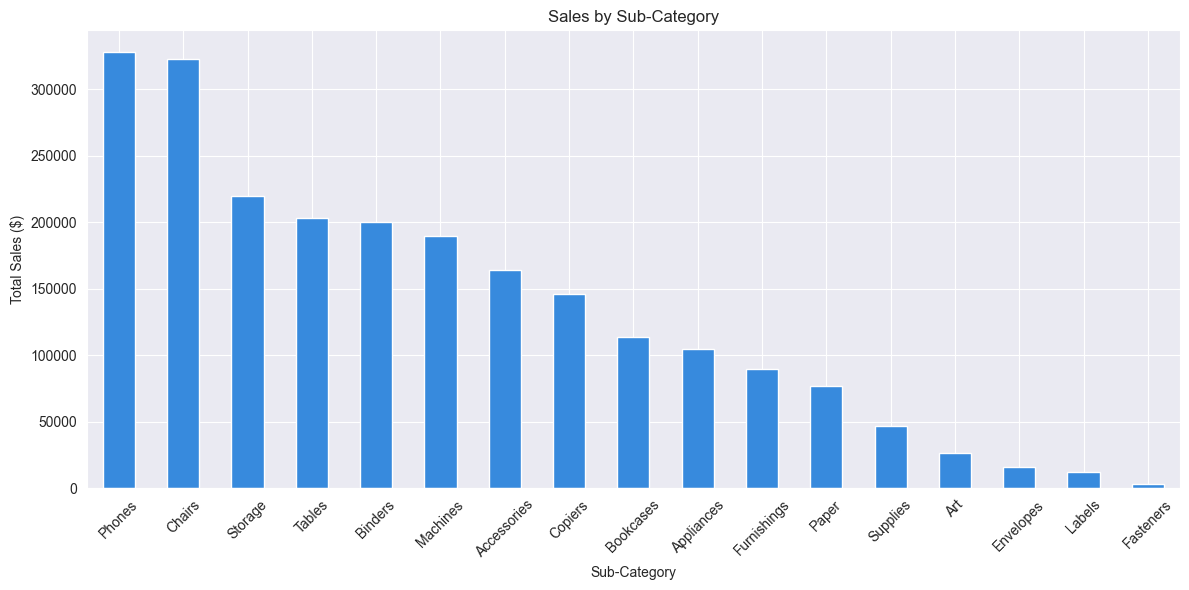

In [15]:
plt.close('all')

sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sub_sales.plot(kind='bar', color='#378ADD')
plt.title('Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Order Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


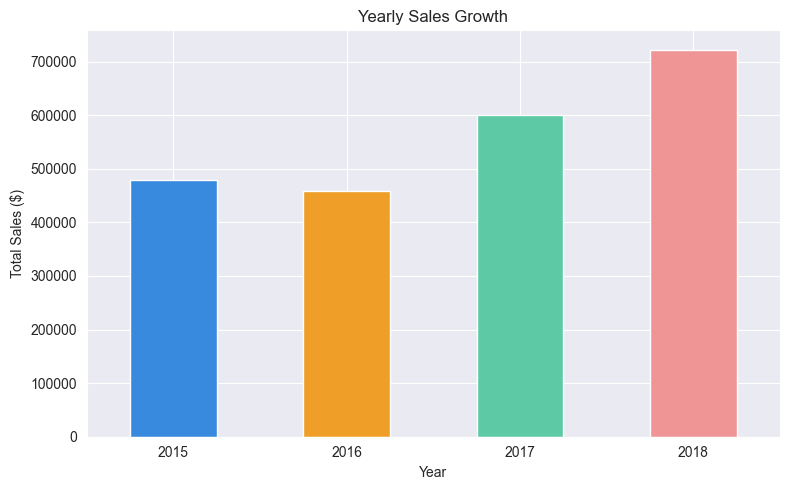

In [16]:
plt.close('all')

yearly_sales = df.groupby('Order Year')['Sales'].sum()
print(yearly_sales)

plt.figure(figsize=(8, 5))
yearly_sales.plot(kind='bar', color=['#378ADD', '#EF9F27', '#5DCAA5', '#F09595'])
plt.title('Yearly Sales Growth')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
import os
print(os.getcwd())

C:\Users\yash0\OneDrive\Desktop\new projects
